In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls /content/drive/MyDrive/sports_dataset.zip

/content/drive/MyDrive/sports_dataset.zip


In [5]:
!unzip "/content/drive/MyDrive/sports_dataset.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/sports_dataset/train/rings/156.jpg  
  inflating: /content/sports_dataset/train/rings/157.jpg  
   creating: /content/sports_dataset/train/rock climbing/
  inflating: /content/sports_dataset/train/rock climbing/001.jpg  
  inflating: /content/sports_dataset/train/rock climbing/002.jpg  
  inflating: /content/sports_dataset/train/rock climbing/003.jpg  
  inflating: /content/sports_dataset/train/rock climbing/004.jpg  
  inflating: /content/sports_dataset/train/rock climbing/005.jpg  
  inflating: /content/sports_dataset/train/rock climbing/006.jpg  
  inflating: /content/sports_dataset/train/rock climbing/007.jpg  
  inflating: /content/sports_dataset/train/rock climbing/008.jpg  
  inflating: /content/sports_dataset/train/rock climbing/009.jpg  
  inflating: /content/sports_dataset/train/rock climbing/010.jpg  
  inflating: /content/sports_dataset/train/rock climbing/011.jpg  
  inflating: /content/sports_dataset

In [6]:
!ls /content/sports_dataset

'EfficientNetB0-100-(224 X 224)- 98.40.h5'   sports.csv   train
 foldernames.txt			     test	  valid


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# CHANGE THIS PATH
base_path = "/content/sports_dataset"

train_path = base_path + "/train"
val_path = base_path + "/valid"
test_path = base_path + "/test"

IMG_SIZE = (224,224)
BATCH_SIZE = 8

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    zoom_range=0.4,
    horizontal_flip=True,
    width_shift_range=0.3,
    height_shift_range=0.3
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

base_model = MobileNetV2(weights='imagenet', include_top=False)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.6)(x)

predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

loss, accuracy = model.evaluate(test_generator)
print("Final Test Accuracy:", accuracy)

model.save("sports_100_model.h5")

Found 13492 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
Found 500 images belonging to 100 classes.


/tmp/ipython-input-3079311956.py:50: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 238s 129ms/step - accuracy: 0.0260 - loss: 5.3687 - val_accuracy: 0.3720 - val_loss: 2.9301
Epoch 2/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 194s 115ms/step - accuracy: 0.1535 - loss: 3.7772 - val_accuracy: 0.5480 - val_loss: 2.0149
Epoch 3/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 193s 114ms/step - accuracy: 0.2815 - loss: 2.9756 - val_accuracy: 0.6740 - val_loss: 1.5055
Epoch 4/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 195s 115ms/step - accuracy: 0.3625 - loss: 2.5446 - val_accuracy: 0.7220 - val_loss: 1.2468
Epoch 5/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 189s 112ms/step - accuracy: 0.4309 - loss: 2.2369 - val_accuracy: 0.7580 - val_loss: 1.0617
Epoch 6/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 189s 112ms/step - accuracy: 0.4627 - loss: 2.0494 - val_accuracy: 0.7580 - val_loss: 0.9601
Epoch 7/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 192s 114ms/step - accuracy: 0.4937 - loss: 1.9165 - val_accuracy: 0.7760 - val_loss: 0.8564
Epoch 8/15
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 193s 115ms/step - ac

Final Test Accuracy: 0.8700000047683716


In [11]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/sports_100_model.h5")
# First freeze everything
for layer in model.layers:
    layer.trainable = False

# Now unfreeze last 30 layers
for layer in model.layers[-30:]:
    layer.trainable = True

print("Trainable layers:")
for layer in model.layers[-10:]:
    print(layer.name, layer.trainable)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)
loss, accuracy = model.evaluate(test_generator)
print("Fine-Tuned Test Accuracy:", accuracy)

model.save("/content/sports_100_model_finetuned.h5")

Trainable layers:
block_16_depthwise_BN True
block_16_depthwise_relu True
block_16_project True
block_16_project_BN True
Conv_1 True
Conv_1_bn True
out_relu True
global_average_pooling2d True
dropout True
dense True
Epoch 1/5
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 229s 125ms/step - accuracy: 0.4317 - loss: 2.2505 - val_accuracy: 0.8180 - val_loss: 0.6786
Epoch 2/5
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 196s 116ms/step - accuracy: 0.5322 - loss: 1.7922 - val_accuracy: 0.8140 - val_loss: 0.6287
Epoch 3/5
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 198s 117ms/step - accuracy: 0.5568 - loss: 1.6436 - val_accuracy: 0.8380 - val_loss: 0.5593
Epoch 4/5
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 202s 120ms/step - accuracy: 0.5843 - loss: 1.5728 - val_accuracy: 0.8460 - val_loss: 0.5176
Epoch 5/5
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 204s 121ms/step - accuracy: 0.6051 - loss: 1.4548 - val_accuracy: 0.8640 - val_loss: 0.4645
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8897 - loss: 0.3831


Fine-Tuned Test Accuracy: 0.8960000276565552


Found 500 images belonging to 100 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Manual Accuracy: 0.896


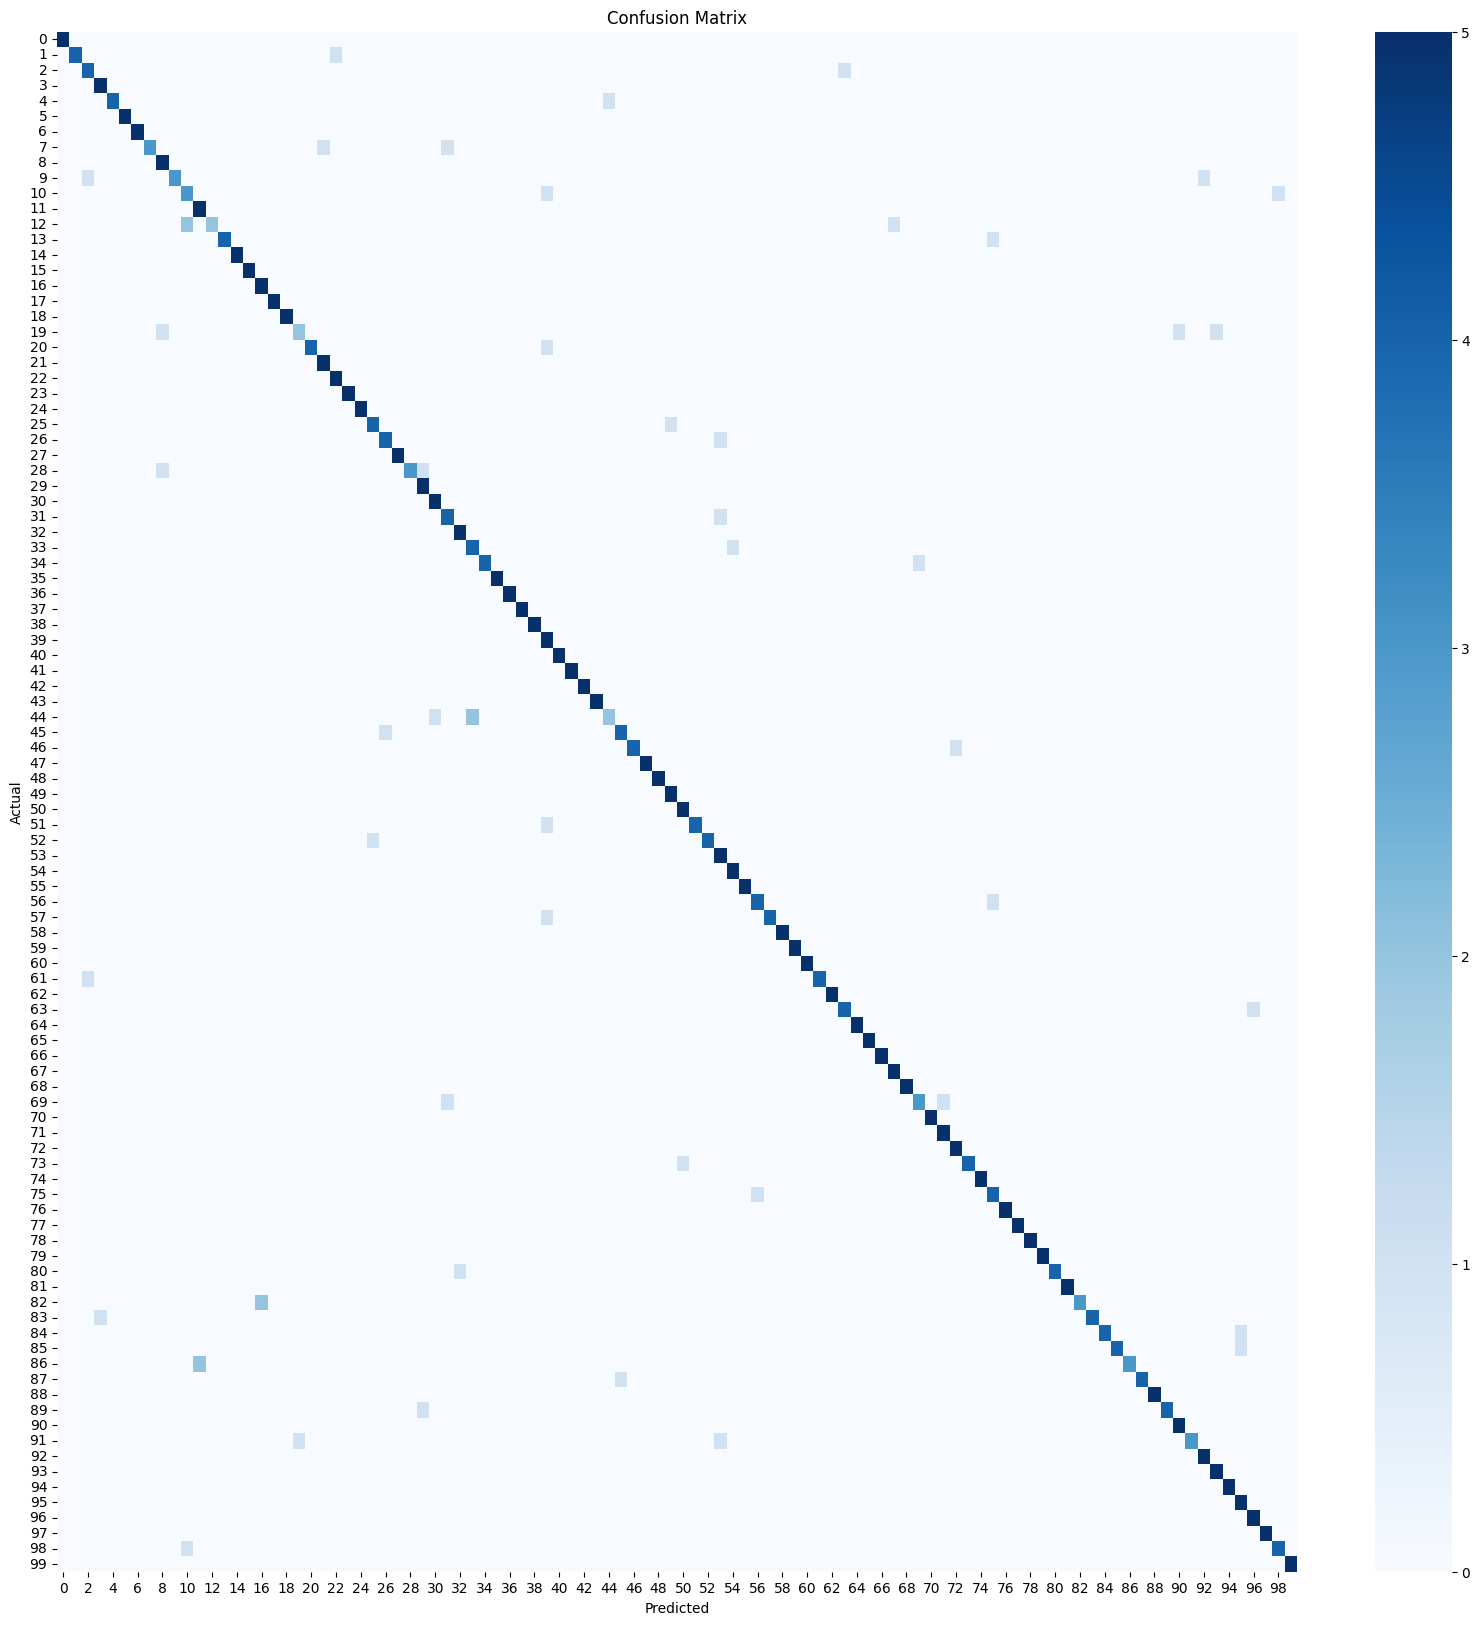

                       precision    recall  f1-score   support

           air hockey       1.00      1.00      1.00         5
      ampute football       1.00      0.80      0.89         5
              archery       0.67      0.80      0.73         5
        arm wrestling       0.83      1.00      0.91         5
         axe throwing       1.00      0.80      0.89         5
         balance beam       1.00      1.00      1.00         5
        barell racing       1.00      1.00      1.00         5
             baseball       1.00      0.60      0.75         5
           basketball       0.71      1.00      0.83         5
       baton twirling       1.00      0.60      0.75         5
            bike polo       0.50      0.60      0.55         5
            billiards       0.71      1.00      0.83         5
                  bmx       1.00      0.40      0.57         5
              bobsled       1.00      0.80      0.89         5
              bowling       1.00      1.00      1.00  

In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 🔥 Recreate test generator EXACTLY same as before
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=8,
    class_mode='categorical',
    shuffle=False   # VERY IMPORTANT
)

# Reset generator
test_generator.reset()

# True labels
y_true = test_generator.classes

# Predictions from CURRENT model (already fine-tuned)
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Manual accuracy check
accuracy = np.mean(y_pred == y_true)
print("Manual Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20,20))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))